In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from netCDF4 import Dataset
import os

In [51]:
rtp = '/Users/pp/data/Simulations/A08_Hydraulics_standalone/2024/Major_update/swiss/local/base'

In [52]:
df = pd.read_csv(f"{rtp}/input/SwissParameterList_03_05100000.csv")

In [53]:
if not os.path.exists(f"{rtp}/post"):
    os.mkdir(f"{rtp}/post")

In [54]:
ds = Dataset(f"{rtp}/output/Sens_Output_agg.nc")
x = ds['RMSE_swiss_trees'][:]
df_res = pd.DataFrame(x)
df_c = pd.concat([df, df_res], axis = 1)

for i in range(0, 14):
    df_i = df_c.sort_values(by = [i]).head(1000).copy()
    df_i.to_csv(f"{rtp}/post/Best_{i}.csv")
    print(i)

range_alive = [1, 4, 9, 10, 11, 12, 13]
range_dead = [0, 3, 6, 7]

0
1
2
3
4
5
6
7
8
9
10
11
12
13


In [78]:
for i in range_dead:
    df_i = df_c.sort_values(by = [i]).head(100).copy()
    df_i.to_csv(f"{rtp}/post/Best_dead_{i}.csv")
    print(i)

0
3
6
7


In [56]:
df_c['mean_alive'] = np.mean(df_c[range_alive].values, axis = 1)

In [65]:
df_i = df_c.sort_values(by = ['mean_alive']).head(100).copy()
df_i.to_csv(f"{rtp}/post/Best_Alive_avg.csv")

(array([11.,  9., 14., 12., 12.,  7., 19., 16.]),
 array([0.80055355, 0.82028413, 0.84001472, 0.8597453 , 0.87947588,
        0.89920647, 0.91893705, 0.93866764, 0.95839822]),
 <BarContainer object of 8 artists>)

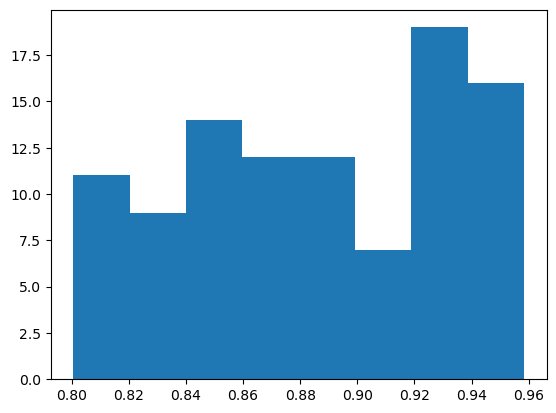

In [79]:
plt.hist(df_i['jackson_root_beta'], bins = 8)

(array([ 4.,  6.,  3.,  7.,  7.,  5.,  6., 20., 18., 24.]),
 array([0.60280583, 0.61051772, 0.6182296 , 0.62594149, 0.63365337,
        0.64136526, 0.64907715, 0.65678903, 0.66450092, 0.6722128 ,
        0.67992469]),
 <BarContainer object of 10 artists>)

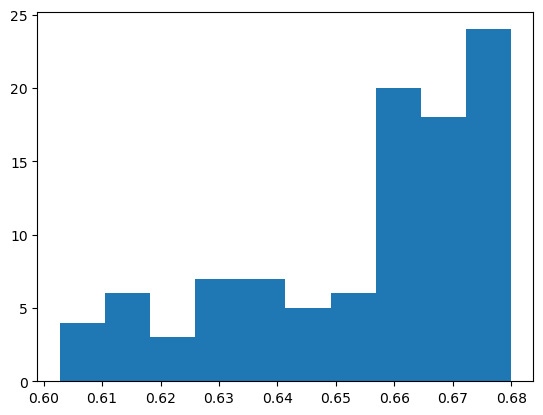

In [80]:
df_i['clay_frac_top'] = df_i['clay_fracs'].str.split(';').str[0].astype(float)
plt.hist(df_i['clay_frac_top'], bins = 10)

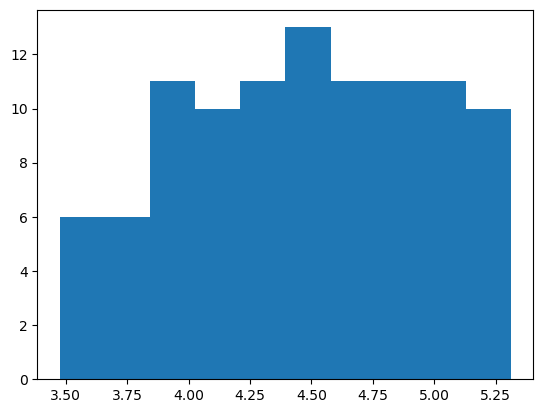

In [81]:
plt.hist(np.log10(df_i['k_xylem_sat']), bins = 10);

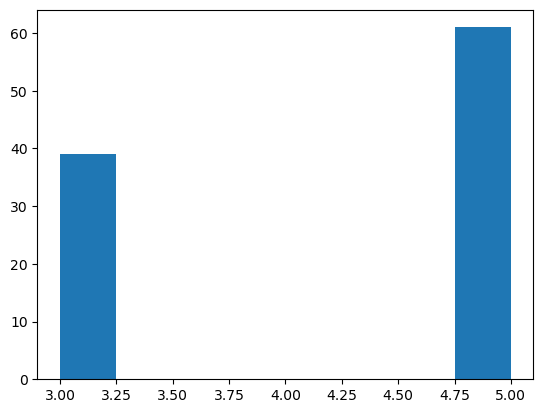

In [82]:
plt.hist(df_i['soil_profile_index'], bins = 8);

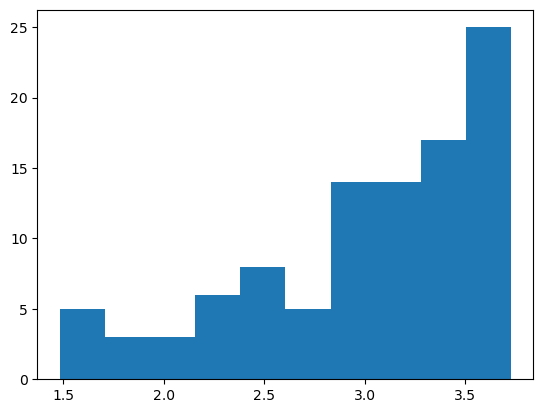

In [83]:
plt.hist(np.log10(df_i['stem_hydraulic_capacitance']), bins = 10);

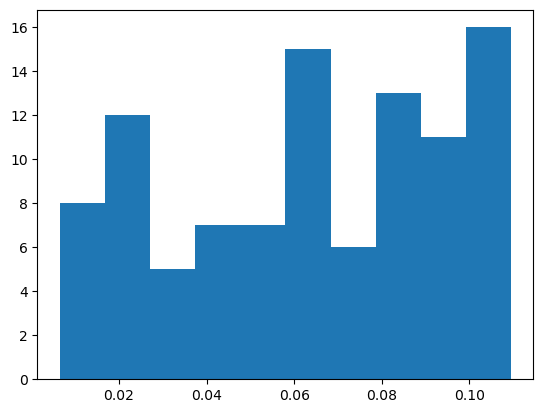

In [84]:
plt.hist(df_i['leaf_hydraulic_capacitance'], bins = 10);

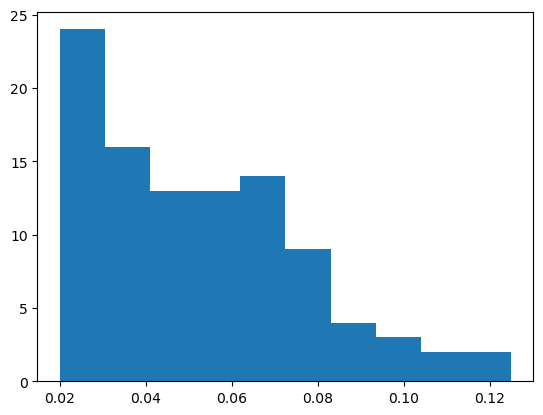

In [85]:
df_i['sand_frac_top'] = df_i['sand_fracs'].str.split(';').str[0].astype(float)
plt.hist(df_i['sand_frac_top'], bins = 10);

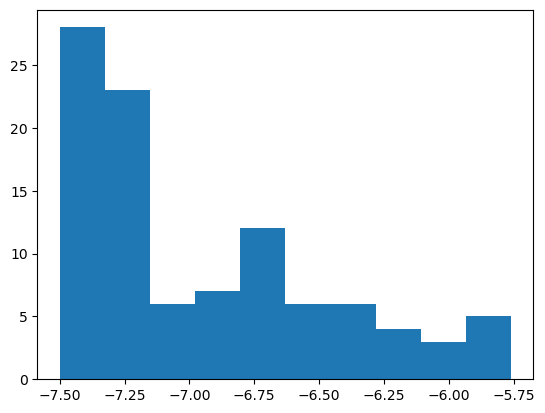

In [86]:
df_i['k_soil_sat_top'] = df_i['k_soil_sats'].str.split(';').str[0].astype(float)
plt.hist(np.log10(df_i['k_soil_sat_top']), bins = 10);